In [44]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.fft import fft, fftfreq
from scipy.signal import detrend

# --- 1. Load ECG Data with HR Labels ---

In [2]:
file_path = os.path.join("data", "ecg_data_with_hr_labels.pkl")  

# Load ECG data
with open(file_path, "rb") as f:
    data = pickle.load(f)
    
# Extract signals and ground truth HR values
signals = data["signals"]
ground_truth_hr = data["hr_values"]

print(f"Loaded {len(signals)} ECG signals.")

Loaded 200 ECG signals.


<Axes: >

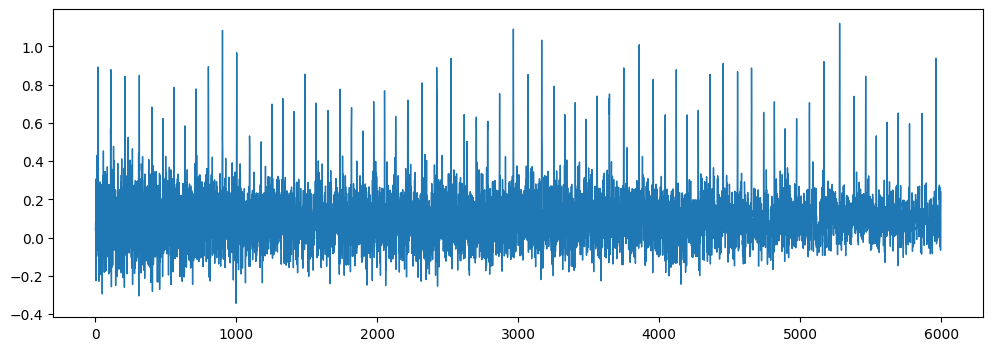

In [51]:
import seaborn as sns
fig, axes = plt.subplots(1, 1, figsize=(12,4))

sns.lineplot(
    signals[1],
    color='tab:blue',
    linewidth=1
)

Text(0.5, 0, 'Frequency (HZ)')

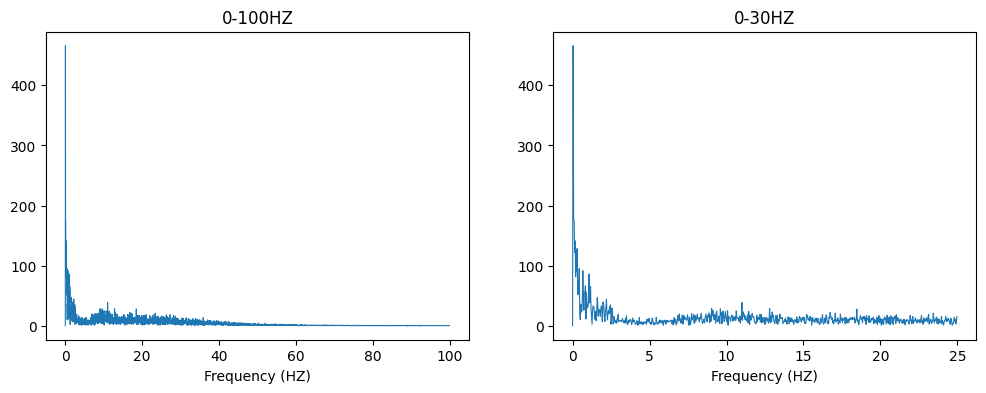

In [50]:
fs = 200
x = signals[3]
N = len(x)

x = x - np.mean(x)

T = 1 / fs

X = fft(x)

f = fftfreq(N, T)  # frequencies

fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.lineplot(ax=axes[0], x=f[:N//2], y=np.abs(X[:N//2]), linewidth=(0.8))

axes[0].set_title("0-100HZ")
axes[0].set_xlabel("Frequency (HZ)")

sns.lineplot(ax=axes[1], x=f[:N//8], y=np.abs(X[:N//8]), linewidth=(0.8)) # zoom for better analysis

axes[1].set_title("0-30HZ")
axes[1].set_xlabel("Frequency (HZ)")

In [63]:
# pan-tompkins pipeline for peak (HR) detection
from scipy.signal import find_peaks
from scipy.signal import butter
from scipy.signal import sosfiltfilt
from scipy.signal import savgol_filter
from scipy.signal import butter, filtfilt
from scipy.signal import lfilter
from scipy.signal import square

In [250]:
f_cut_ecg=[0.5, 15.0] # test


# highpass & lowpass --> bandpass
def bandpass_filter(s, fs, fcut, order=4):
    nyq = fs / 2
    b, a = butter(order, [fcut[0]/nyq, fcut[1]/nyq], btype='band')
    return filtfilt(b, a, s)



def derivative_filter(ecg, fs):
    T = 1 / fs

    # 1D five-point stencil
    b = np.array([-1, -2, 0, 2, 1]) / (8 * T)
    
    #print(b)
    return filtfilt(b, [1], ecg)

# https://medium.com/@cosmicwanderer/pan-tompkins-algorithm-for-detecting-qrs-waves-29c5f2927906

def moving_average(ECG, N=30):
    
    window  = np.ones((1,N))/N
    ECG_ma  = np.convolve(np.squeeze(ECG),np.squeeze(window), mode='same')
    return ECG_ma

# --- 2. Implement Your HR Extraction Algorithm Here ---

**Instruction:**

***Your algorithm should return a list of HR values where each HR value corresponds to an ECG signal. Ensure the length of the list is 200 (equal to number of signals). The list can include np.nan if your algorithm is not able to calculate HR for a signal.***

In [251]:
def extract_hr(ecg_signals):
    """
    Dummy HR extraction function.
    Replace this with your actual algorithm.
    """
    detected_hr_values = [np.nan] * 200  # Ensuring list has 200 elements 
    
    for i, signal in enumerate(ecg_signals):  

        bandpass = bandpass_filter(signal, fs, f_cut_ecg, order=4)

        derivative = derivative_filter(bandpass, fs)

        
        squared = derivative ** 2
        ma = moving_average(squared, N=30)

        peaks, props= find_peaks(
        ma,
        height=np.mean(ma),
        distance=int(0.3 * fs),
        prominence=0.2 * np.std(ma)
    )
        
        detected_hr_values[i] = peaks  # Modify this with your method
    return detected_hr_values



# Run your HR extraction algorithm
detected_hr_values = extract_hr(signals)

In [252]:
print(len(detected_hr_values))

200


In [253]:
def map_peaks_to_ecg(mwi_peaks, s, fs, search_ms=150):
    mapped_peaks = []
    half_window = int((search_ms / 1000) * fs)
    print(half_window)

    for p in mwi_peaks:
        start = max(p - half_window, 0)
        end   = min(p + half_window, len(s))
        local_max = np.argmax(s[start:end]) + start

        mapped_peaks.append(local_max)

    return np.array(mapped_peaks)

In [254]:
ecg_peaks = map_peaks_to_ecg(detected_hr_values[3], signals[3], fs)
t = np.arange(len(signals[3])) / fs

30


In [255]:
print(len(ecg_peaks))
print(ground_truth_hr[3])

61
130.191557891168


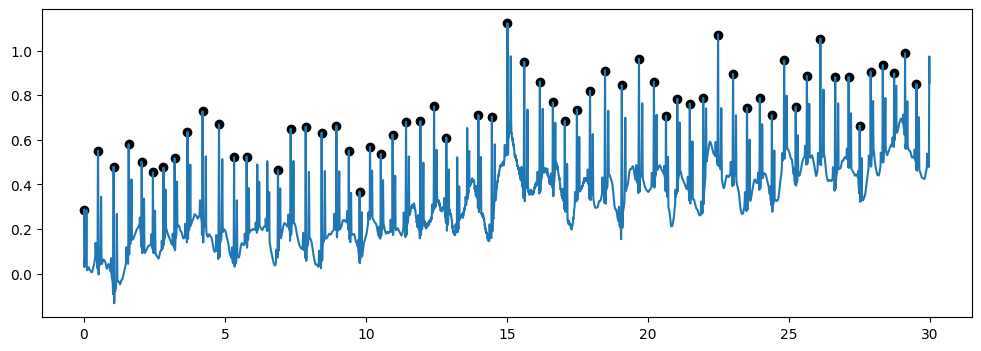

In [256]:


fig, axes = plt.subplots(1, 1, figsize=(12,4))

plt.plot(t, signals[3])
plt.scatter(
    t[ecg_peaks],
    signals[3][ecg_peaks],
    color='black'
)

In [257]:
def pipeline(detected_peaks, signals):

    peaks_mapped = []

    for peaks, signal in zip(detected_peaks, signals):
        ecg_peaks = map_peaks_to_ecg(peaks, signal, fs)
        peaks_mapped.append(ecg_peaks)

    return peaks_mapped

In [258]:
peaks_mapped = pipeline(detected_hr_values, signals)

30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30


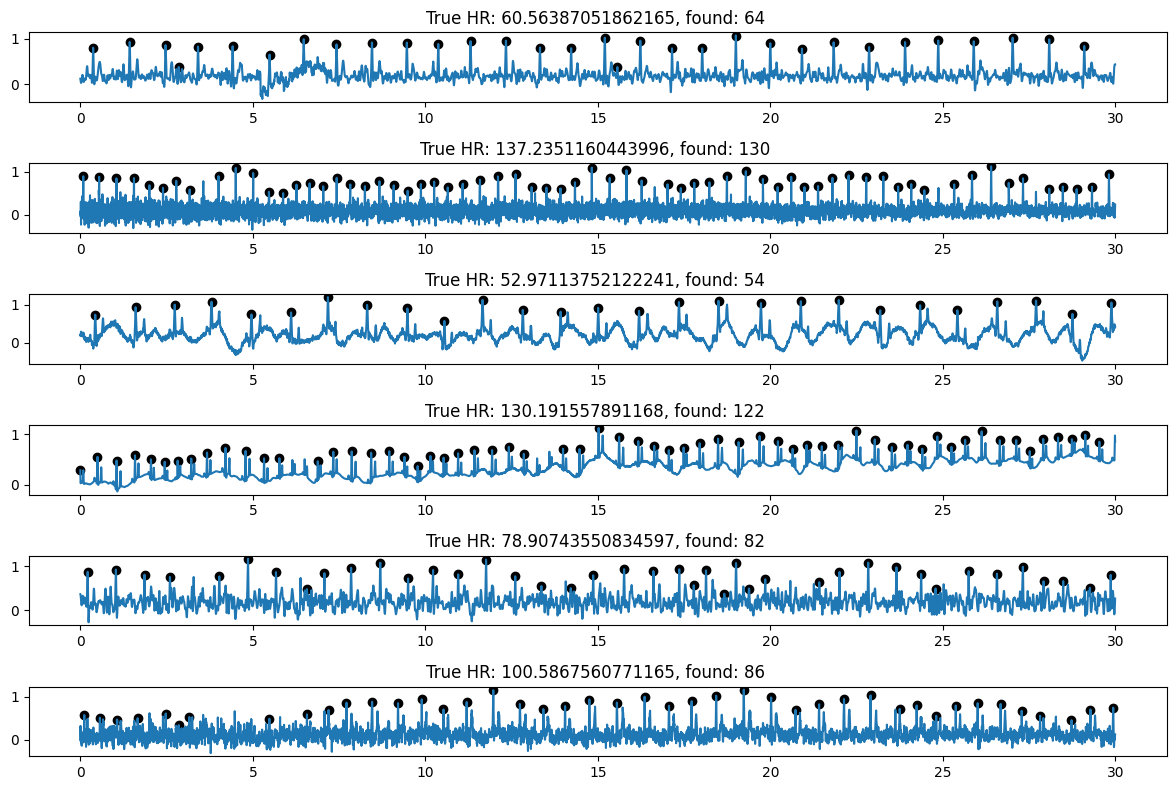

In [259]:
iters = 6
fig, axes = plt.subplots(iters, 1, figsize=(12,8))

for i in range(iters):
    
    peaks = peaks_mapped[i]
    
    axes[i].plot(t, signals[i])
    axes[i].scatter(
        t[peaks],
        signals[i][peaks],
        color='black'
    )
    
    axes[i].set_title(f"True HR: {ground_truth_hr[i]}, found: {len(peaks_mapped[i])*2} ")

plt.tight_layout()

In [260]:
print(len(peaks_mapped))
peak_counts = [len(peaks)*2 for peaks in peaks_mapped]

200


# --- 3. Evaluation of HR Extraction Algorithm ---

**Description:**

***Evaluates the performance of your HR extraction method using Mean Absolute Error (MAE).***

In [261]:
def evaluate_hr_extraction(detected_hr_values, ground_truth_hr):
    """
    Evaluates HR extraction performance using Mean Absolute Error (MAE).
    
    Parameters:
        - detected_hr_values (List of floats): List of detected HR values.
        - ground_truth_hr (List of floats): List of ground truth HR values.
    
    Returns:
        - MAE score.
    """
    valid_indices = np.where(~np.isnan(detected_hr_values))[0].tolist() 
    
    if len(valid_indices) == 0:
        return {"Mean Absolute Error": np.nan}
    
    absolute_errors = np.abs(np.array(ground_truth_hr)[valid_indices] - np.array(detected_hr_values)[valid_indices])
    mae = np.sum(absolute_errors) / len(absolute_errors)
    return {"Mean Absolute Error": mae}

In [262]:
# Evaluate performance of your HR extraction method
mae = evaluate_hr_extraction(peak_counts, ground_truth_hr)

print(mae)

{'Mean Absolute Error': np.float64(7.539874538399278)}


***Run the above cells and check your evaluation score.***

***The final assessment is based on the MAE, the lowest MAE is the first rank in competition!***